In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [9]:
#functions

# def add_bias(x):
#   return np.hstack((np.ones((x.shape[0], 1)), x))

# def sigmoid(z): #sigmoid function
#   return 1 / (1 + np.exp(-z))

# # binary cross-entropy loss plus optional lambda weight penalty
# def compute_loss(theta, X, y, lam=0):
#     m = len(y)
#     h = sigmoid(X @ theta) #run sigmoid function
#     # h = np.clip(h, 1e-12, 1 - 1e-12)  # avoid log(0)
#     cross_entropy = -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h)) #binary cross-entropy loss of J(theta)
#     penalty = (lam / (2 * m)) * np.sum(theta[1:] ** 2)   # theta[0] is not penalized
#     return cross_entropy + penalty

def plot_training(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(history["train_loss"], label="Training loss")
    ax1.plot(history["val_loss"], label="Validation loss")
    ax1.set_title(title + ": Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Binary cross-entropy")
    ax1.legend()
    ax1.grid(alpha=0.01)

    ax2.plot(history["train_acc"], label="Training accuracy")
    ax2.plot(history["val_acc"], label="Validation accuracy")
    ax2.set_title(title + ": Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0.6, 1.2)
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


#prints the classification metrics and plots the confusion matrix for the validation set
def report_results(model, X_val, y_val, class_names, title):
    y_pred = model.predict(X_val)

    print(title, "- validation results")
    print("Recall   :", round(sklearn.metrics.recall_score(y_val, y_pred), 4)) # TP / (TP+FN)
    print("Precision:", round(sklearn.metrics.precision_score(y_val, y_pred), 4)) # TP / (TP+FP)
    print("Accuracy :", round(sklearn.metrics.accuracy_score(y_val, y_pred), 4)) # (TP + TN)/#ofpredictions
    print("F1 score :", round(sklearn.metrics.f1_score(y_val, y_pred), 4)) # (2*precision*recall)/(precision+recall)


    matrix = sklearn.metrics.confusion_matrix(y_val, y_pred)
    sklearn.metrics.ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(cmap="Blues")
    plt.title("Confusion matrix: " + title)
    plt.show()


In [10]:
#Datasetinput Problem 1
url = 'https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/main/Dataset/diabetes.csv'

db = pd.DataFrame(pd.read_csv(url))
db = db[['Outcome'] + [col for col in db.columns if col != 'Outcome']] #moves y to col 1

db = db[(db.drop('Outcome', axis=1) != 0).all(axis=1)] #removes all rows with any input values of 0

db.head()


,Outcome,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
3,0,1,89,66,23,94,28.1,0.167,21
6,1,3,78,50,32,88,31.0,0.248,26
8,1,2,197,70,45,543,30.5,0.158,53
13,1,1,189,60,23,846,30.1,0.398,59
14,1,5,166,72,19,175,25.8,0.587,51


Features: 8   Training rows: 268   Validation rows: 68


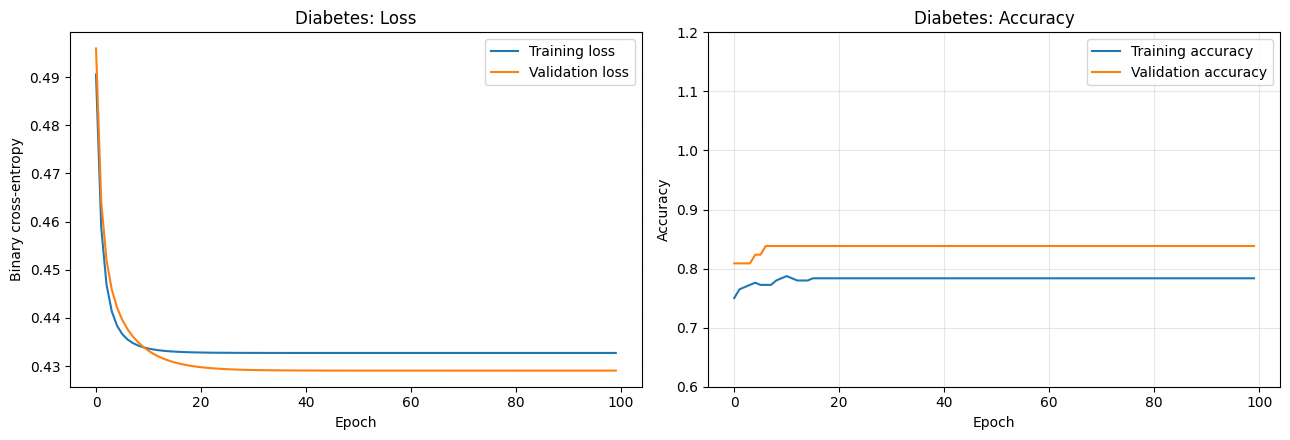

Diabetes - validation results
Recall   : 0.6818
Precision: 0.7895
Accuracy : 0.8382
F1 score : 0.7317


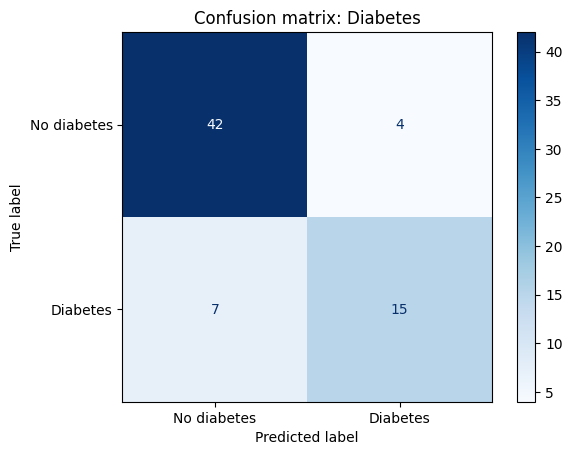

In [11]:
#Problem 1

X = db.drop('Outcome', axis=1).values
y = db['Outcome'].values

# 80/20 training/validation
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=163)

#standardize inputs
scaler = sklearn.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Features:", X.shape[1], "  Training rows:", len(y_train), "  Validation rows:", len(y_val))

#training
m = len(y_train)
epochs=100
learning_rate=0.01
lam=0

#sklearn Logistic Regression, alpha=>eta0, lambda=>alpha
model = sklearn.linear_model.SGDClassifier(loss="log_loss", penalty=None,learning_rate="constant", eta0=learning_rate, random_state=42)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(epochs):
  # One pass of gradient descent over the training data
  model.partial_fit(X_train, y_train, classes=[0, 1])

  # Score the current weights on both sets (no learning here)
  history["train_loss"].append(sklearn.metrics.log_loss(y_train, model.predict_proba(X_train)))
  history["val_loss"].append(sklearn.metrics.log_loss(y_val, model.predict_proba(X_val)))
  history["train_acc"].append(model.score(X_train, y_train))
  history["val_acc"].append(model.score(X_val, y_val))

plot_training(history, "Diabetes")
report_results(model, X_val, y_val, ["No diabetes", "Diabetes"], "Diabetes")


In [12]:
#Datasetinput Problem 2
url = 'https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/main/Dataset/Cancer.csv'
dc = pd.DataFrame(pd.read_csv(url))
dc = dc.drop(["id", "Unnamed: 32"], axis=1) #id is not needed

dc = dc[(dc != 0).all(axis=1)]
dc.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Features: 30   Training rows: 444   Validation rows: 112


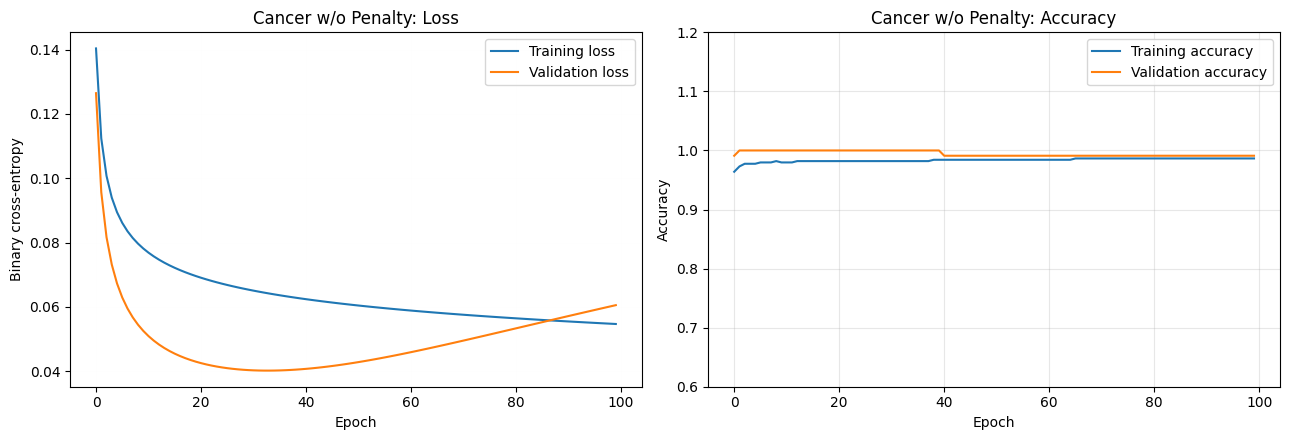

Cancer (no penalty) - validation results
Recall   : 0.9787
Precision: 1.0
Accuracy : 0.9911
F1 score : 0.9892


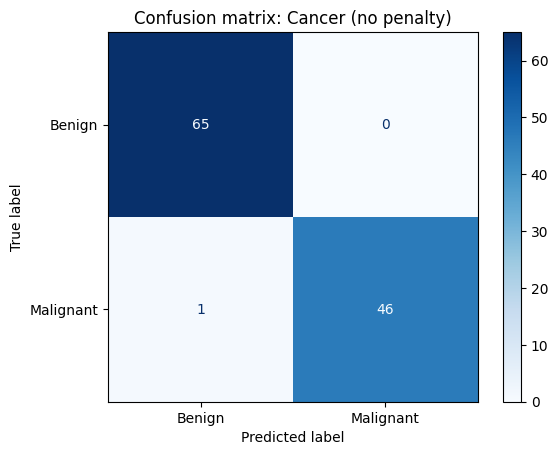

In [13]:
#Problem 2.1
X = dc.drop(columns="diagnosis")
y = (dc["diagnosis"] == "M").astype(int).values
feature_names = X.columns

# 80/20 training/validation
X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=163)

#standardize
scaler = sklearn.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Features:", X.shape[1], "  Training rows:", len(y_train), "  Validation rows:", len(y_val))




#training
m = len(y_train)
epochs=100
learning_rate=0.01
lam=0

model_no_penalty = sklearn.linear_model.SGDClassifier(loss="log_loss", penalty=None,learning_rate="constant", eta0=learning_rate, random_state=42)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(epochs):

  model_no_penalty.partial_fit(X_train, y_train, classes=[0, 1])

  history["train_loss"].append(sklearn.metrics.log_loss(y_train, model_no_penalty.predict_proba(X_train)))
  history["val_loss"].append(sklearn.metrics.log_loss(y_val, model_no_penalty.predict_proba(X_val)))
  history["train_acc"].append(model_no_penalty.score(X_train, y_train))
  history["val_acc"].append(model_no_penalty.score(X_val, y_val))

plot_training(history, "Cancer w/o Penalty")
report_results(model_no_penalty, X_val, y_val, ["Benign", "Malignant"], "Cancer (no penalty)")

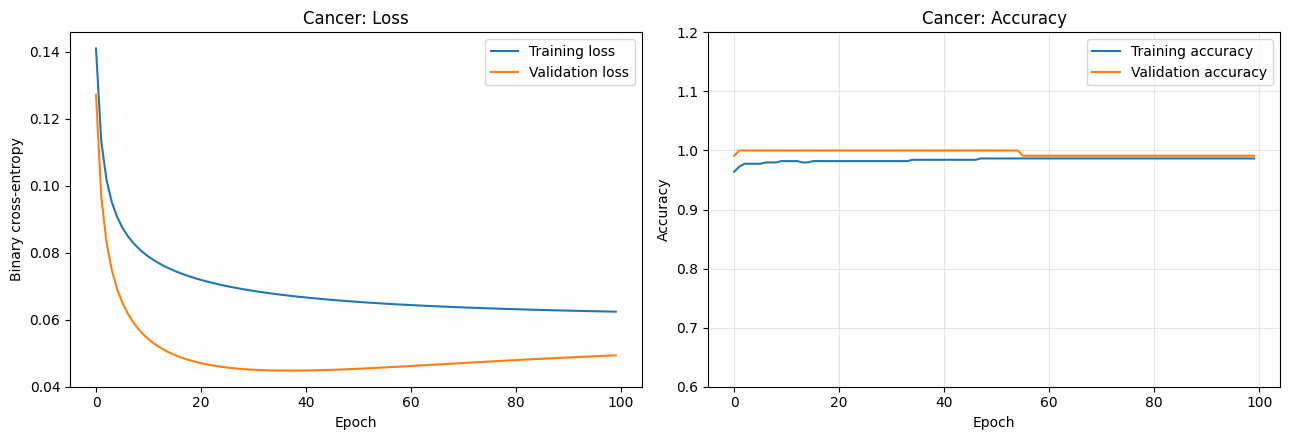

Cancer (no penalty) - validation results
Recall   : 0.9787
Precision: 1.0
Accuracy : 0.9911
F1 score : 0.9892


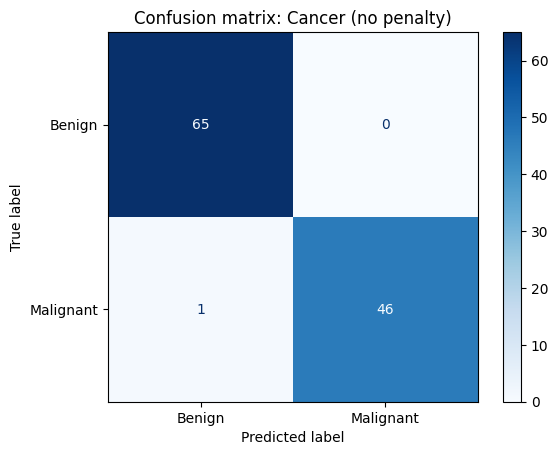

In [14]:
#problem 2.2

#training
m = len(y_train)
epochs=100
learning_rate=0.01
lam=1

# L2 weight penalty: alpha = lambda / m matches (lambda / 2m) * sum(theta_j^2)
model_penalty = sklearn.linear_model.SGDClassifier(loss="log_loss", penalty="l2",alpha=(lam / m),learning_rate="constant", eta0=learning_rate, random_state=42)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(epochs):

  model_penalty.partial_fit(X_train, y_train, classes=[0, 1])

  history["train_loss"].append(sklearn.metrics.log_loss(y_train, model_penalty.predict_proba(X_train)))
  history["val_loss"].append(sklearn.metrics.log_loss(y_val, model_penalty.predict_proba(X_val)))
  history["train_acc"].append(model_penalty.score(X_train, y_train))
  history["val_acc"].append(model_penalty.score(X_val, y_val))

plot_training(history, "Cancer")
report_results(model_penalty, X_val, y_val, ["Benign", "Malignant"], "Cancer (no penalty)")